<div dir="rtl" style="text-align: right; font-size: 28px; font-weight: bold; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 20px; border-radius: 10px; margin-bottom: 20px;">

# Week 9: The Attention Mechanism and Transformers

بعد ما شفنا ال RNN في Week 8

النهاردة هنشوف Attention Mechanisms والـ Transformers بإذن الله!

</div>

## Overview

**Instructor:** Dr. Mahmoud Eid (m.eid@fci-cu.edu.eg)

**Estimated Time:** 3-4 hours

**What You'll Learn:**

**Main Example: News Classification (Many-to-One)**

- Complete working code with BiLSTM, BiLSTM+Attention, Transformer
- AG News dataset (4 categories)

**Practice Exercise: Company/Person NER (Many-to-Many)**

- Your turn to implement!
- Apply Attention and Transformers to NER

**Prerequisites:** PyTorch (Week 5), RNN Models (Week 8), Attention (Lecture 16)

---


<div dir="rtl" style="text-align: right; font-size: 28px; font-weight: bold; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 20px; border-radius: 10px; margin-bottom: 20px;">

# Attention و Transformers لتصنيف الأخبار

</div>

---


## Setup and Imports


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import accuracy_score
from collections import Counter
from datasets import load_dataset
import random
import math
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('dark_background')
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

# Main Example: News Classification (Many-to-One)

</div>

**Task:** Given a news article, classify it into one of **4 categories**:

- 0: World
- 1: Sports
- 2: Business
- 3: Sci/Tech

**Dataset:** AG News - Real news articles from 4 major categories

**Challenges:**

- 4-class classification
- Varied article lengths
- Domain-specific vocabulary
- Subtle differences between categories

**Goal:** Train models to understand news topics for automated content organization

## Load Dataset


In [2]:
# Load AG News dataset (4-class news classification)
print("Loading AG News dataset...")

train_data = load_dataset("ag_news", split='train')
test_data = load_dataset("ag_news", split='test')

# Sample subsets for faster training
train_data = train_data.shuffle(seed=42).select(range(15000))  # (15000, 2)
test_data = test_data.shuffle(seed=42).select(range(3000))     # (3000, 2)

# Define class names
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

print(f"\nDataset: AG News")
print(f"Train: {len(train_data)} articles")
print(f"Test: {len(test_data)} articles")
print(f"\nClasses:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

print(f"\nSample article:")
print(f"Text: {train_data[14]['text'][:300]}...")
print(f"Label: {train_data[0]['label']} ({class_names[train_data[0]['label']]})")

# Analyze article lengths
train_lengths = [len(article['text'].split()) for article in train_data] # get len words for each article of 15000 articles in train_data
print(f"\nArticle length statistics:")
print(f"  Average: {np.mean(train_lengths):.1f} words")
print(f"  Median: {np.median(train_lengths):.1f} words")
print(f"  Max: {np.max(train_lengths)} words")

Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


Dataset: AG News
Train: 15000 articles
Test: 3000 articles

Classes:
  0: World
  1: Sports
  2: Business
  3: Sci/Tech

Sample article:
Text: Oracle acquisition of PeopleSoft leads flurry of deals NEW YORK (CBS.MW) -- US stocks closed higher Monday, with the Dow Jones Industrial Average ending at its best level in more than nine months amid better-than-expected economic data and merger-related optimism....
Label: 0 (World)

Article length statistics:
  Average: 37.9 words
  Median: 37.0 words
  Max: 157 words


In [3]:
import pandas as pd
pd.DataFrame(train_data)

,text,label
0,Bangladesh paralysed by strikes Opposition act...,0
1,Desiring Stability Redskins coach Joe Gibbs ex...,1
2,Will Putin #39;s Power Play Make Russia Safer?...,0
3,U2 pitches for Apple New iTunes ads airing dur...,3
4,S African TV in beheading blunder Public broad...,0
...,...,...
14995,Big East to be one 16-team division in 2005-06...,1
14996,US pounds Falluja A suicide car bomber killed ...,0
14997,"Another Seahawks Linebacker Hurt KIRKLAND, Wa...",1
14998,A burgeoning billionaires #39; club There are ...,2


In [4]:
l = [len(article['text'].split()) for article in train_data]
float(f"{np.mean(l):.2f}")

37.86

## Build Vocabulary and GloVe Embeddings


In [5]:
# Build vocabulary for news dataset
print("Building vocabulary...")

vocab = {'<PAD>': 0, '<UNK>': 1}
word_counts = Counter()
#  removes rare words that might be noise
for sample in train_data:
    words = sample['text'].lower().split()  # list of words
    word_counts.update(words)

# Add words appearing at least 5 times
for word, count in word_counts.items():      # (51925 items) collections.Counter{'bangladesh': 46, 'paralysed': 2, 'by': 2577, 'strikes': 35, 'opposition': 125, ...}
    if count >= 5 and word not in vocab:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")     # (10971 items) {'<PAD>': 0, '<UNK>': 1, 'bangladesh': 2, 'by': 3, 'strikes': 4, ...

Building vocabulary...
Vocabulary size: 10971


In [6]:
# note in here how i didn't give you the file but i uploaded it to my google drive
# so that you can download them to your colab machine
# glove_path = 'https://drive.google.com/file/d/1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q/view?usp=sharing'
import gdown

# Google Drive file ID from my link
file_id = "1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q"
url = f"https://drive.google.com/uc?id={file_id}"

output = "glove_vectors.txt"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q
From (redirected): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q&confirm=t&uuid=4ad65e08-66d1-475a-a26c-e3c257c86992
To: /content/glove_vectors.txt
100%|██████████| 1.68G/1.68G [00:25<00:00, 65.3MB/s]


'glove_vectors.txt'

In [7]:
# Load pre-trained GloVe embeddings (reuse from Part 1 if available)
EMBEDDING_DIM = 100


print("Loading GloVe embeddings...")
# glove_path = 'glove.2024.wikigiga.100d\wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt'
glove_path = 'glove_vectors.txt'

# Load GloVe vectors with error handling
glove_vectors = {}
skipped = 0

with open(glove_path, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f):
        try:
            values = line.rstrip().split(' ')
            word = values[0]
            vector = np.array(values[1:], dtype='float32')

            if len(vector) == EMBEDDING_DIM:
                glove_vectors[word] = vector
            else:
                skipped += 1
        except (ValueError, IndexError):
            skipped += 1
            continue

        if (line_num + 1) % 100000 == 0:
            print(f"  Processed {line_num + 1:,} lines...")

print(f"\nLoaded {len(glove_vectors):,} GloVe vectors")
if skipped > 0:
    print(f"Skipped {skipped:,} malformed lines")

Loading GloVe embeddings...
  Processed 100,000 lines...
  Processed 200,000 lines...
  Processed 300,000 lines...
  Processed 400,000 lines...
  Processed 500,000 lines...
  Processed 600,000 lines...
  Processed 700,000 lines...
  Processed 800,000 lines...
  Processed 900,000 lines...
  Processed 1,000,000 lines...
  Processed 1,100,000 lines...
  Processed 1,200,000 lines...

Loaded 1,291,147 GloVe vectors


In [8]:
# Create embedding matrix
embedding_matrix = np.random.randn(len(vocab), EMBEDDING_DIM).astype('float32') * 0.01 # Initialize random embeddings -- Initialize random embeddings
embedding_matrix[vocab['<PAD>']] = np.zeros(EMBEDDING_DIM)

found_count = 0
for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found_count += 1

print(f"\nEmbedding matrix shape: {embedding_matrix.shape}")
print(f"Found GloVe vectors for {found_count}/{len(vocab)} words ({100*found_count/len(vocab):.1f}%)")
print("Ready for news classification!")


Embedding matrix shape: (10971, 100)
Found GloVe vectors for 8854/10971 words (80.7%)
Ready for news classification!


## Create PyTorch Dataset and DataLoader


In [9]:
class NewsDataset(Dataset):
    def __init__(self, data, vocab, max_len=400):
        self.data = data
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['text'].lower().split()[:self.max_len]
        label = self.data[idx]['label']

        word_ids = [self.vocab.get(word, self.vocab['<UNK>']) for word in text]
        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


def news_collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=vocab['<PAD>'])
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_texts, labels, lengths


# Create datasets
train_dataset = NewsDataset(train_data, vocab, max_len=400)
test_dataset = NewsDataset(test_data, vocab, max_len=400)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=news_collate_fn) # 32 batch each batch has 469 sentences (len(train_dataset)/32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=news_collate_fn)

print(f"Dataloaders ready!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

Dataloaders ready!
  Train batches: 469
  Test batches: 94


---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

## Model Implementations النماذج

</div>

We'll implement and compare:

1. **BiLSTM** - Baseline sequential model
2. **BiLSTM + Attention** - Focuses on key words
3. **Transformer** - Parallel processing with multi-head attention


In [10]:
# Model 1: BiLSTM (Baseline)  --> This is a bidirectional LSTM for classifying news articles into 4 categories

class BiLSTMSentiment(nn.Module):
    """Standard BiLSTM for news classification"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)  # Creates a lookup table that converts word IDs → word vectors (padding_idx=0 means word ID 0 (padding) gets a zero vector)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))     # Loads pre-trained GloVe embeddings into this table  -- Example: If word "cat" has ID 42, embedding(42) returns a 100-dimensional vector representing "cat"
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True,
                            num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, 4)  # 4 classes for AG News   ---  hidden_dim * 2 -> BiLSTM outputs 2 hidden states (one from each direction) - If hidden_dim=128, 128 (forward) + 128 (backward) = 256 total

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # Convert word IDs to vectors --> Input: [5, 23,..] (word IDs) -> Output: [[0.2, -0.5, ...], [0.1, 0.3, ...], ...] (4 vectors of 100 dimensions)
        embedded = self.dropout(embedded)

        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        output, (hidden, cell) = self.lstm(packed)

        # Use last hidden states from both directions
        hidden_fwd = hidden[-2, :, :]    # Last forward direction ->   [batch, 128]
        hidden_bwd = hidden[-1, :, :]    # Last backward direction ->  [batch, 128]
        hidden_combined = torch.cat([hidden_fwd, hidden_bwd], dim=1) # Concatenate along dimension 1 → [batch, 256]

        hidden_combined = self.dropout(hidden_combined)
        logits = self.fc(hidden_combined) # Map to 4 class scores -> Convert the combined hidden state (256-dim) → 4 scores (one per class)
        return logits


print("BiLSTM model defined")

BiLSTM model defined


```py
self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True,
                    bidirectional=True, num_layers=2, dropout=0.3)
bidirectional=True: Reads text left→right AND right→left simultaneously
num_layers=2: Stacks 2 LSTM layers (deeper = more capacity to learn patterns)
dropout=0.3: Randomly drops 30% of connections between layers to prevent overfitting
Why bidirectional?
In "The movie was not good", you need context from BOTH sides to understand "not". Reading backwards helps!
```
```
Why pack sequences? in pack_padded_sequence()
News articles have different lengths (50 words, 200 words, etc.)
Padding makes them equal length, but wastes computation on padding tokens
Packing tells PyTorch: "Skip the padding, only process real words"
```
```py
output, (hidden, cell) = self.lstm(packed)
output = your thoughts after EACH word: ["I", "I love", "I love machine", "I love machine learning"]
- Hidden states at EVERY word in the sentence
- Shape: [batch, sequence_length, hidden_dim * 2]
- Example: For "I love ML" → you get 3 hidden states (one after each word)

hidden -> ONLY your FINAL thought: "I love machine learning"
- ONLY the LAST hidden state from each layer/direction
- Shape: [num_layers * num_directions, batch, hidden_dim]
- With 2 layers + bidirectional = 4 total: [Layer1_Fwd, Layer1_Bwd, Layer2_Fwd, Layer2_Bwd]
cell -> LSTM's internal memory (we ignore this for classification)

In this BiLSTM model: We only use hidden (the final states) to classify the news article.
```
```py
Imagine `num_layers=2`, `bidirectional=True`. The `hidden` tensor looks like:
hidden[0] = Layer 1, Forward direction  →   # [[0.1,..], [0.3,..], [0.5,..], ..] -> [sentence 1, sentence 2, sentence 3,..]
hidden[1] = Layer 1, Backward direction ←
hidden[2] = Layer 2, Forward direction  →
hidden[3] = Layer 2, Backward direction ←
We want the LAST layer's output:
hidden[-2] = hidden[2] = Layer 2 forward →
hidden[-1] = hidden[3] = Layer 2 backward ←   # Take the LAST item (index 3) -> Shape: [no. of sentence (batch), 128] - all sentences, all hidden dimensions
hidden_fwd = hidden[-2, :, :]  # [batch, 128] Layer 2 Backward
hidden_bwd = hidden[-1, :, :]  # [batch, 128] Layer 2 Forward
Then concatenate them: [forward_vector | backward_vector] # → [batch, 256]
Why concatenate? Because the forward LSTM captures "what came before" and backward LSTM captures "what comes after". Together they give full context!
```
```
Embed words → vectors
Process with BiLSTM (captures context from both directions)
Take the final hidden states from both directions
Combine them together
Classify into 4 news categories
Key limitation: It only uses the final hidden state for classification. It ignores all the intermediate hidden states from the words in between. This is what Attention will fix in the next model!
```

In [11]:
# Model 2: BiLSTM + Attention

class BiLSTMAttention(nn.Module):
    """BiLSTM with attention mechanism"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True,
                            num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.5)

        # Attention layer
        self.attention = nn.Linear(hidden_dim * 2, 1)  # produces one score per word --- *2 because we use BiLSTM so both directions
        self.fc = nn.Linear(hidden_dim * 2, 4)  # 4 classes for AG News

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        # LSTM encoding -> we use output instead of just hidden
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        output, _ = self.lstm(packed)  # Hidden states for **EVERY word** in the sentence -- Shape: `[batch_size, sequence_length, hidden_dim * 2]`
        output, _ = torch.nn.utils.rnn.pad_packed_sequence(output, batch_first=True) # unpacked it (Padding is removed internally)

        # Attention mechanism
        attention_scores = self.attention(output).squeeze(-1)  # Calculate attention scores for each word

        # Mask padding .. so we put the value with very high negative number to give them attention of zero
        # because padded tokens should not be considered
        max_len = attention_scores.size(1) # 3 (Because it 1 accross words)
        mask = torch.arange(max_len, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)  # “Create a tensor [0, 1, ..., max_len-1] on the same device as x.” -> tensor([0, 1, 2], device='cuda:0') -> (device where the input tensor lives (GPU - CPU))
        attention_scores = attention_scores.masked_fill(~mask, -1e9)

        attention_weights = F.softmax(attention_scores, dim=1)

        # Weighted sum
        weighted_output = (output * attention_weights.unsqueeze(-1)).sum(dim=1)

        weighted_output = self.dropout(weighted_output)
        logits = self.fc(weighted_output)   # Classification  -> map 256 dims to 4 classes scores
        return logits, attention_weights


print("BiLSTM + Attention model defined")

BiLSTM + Attention model defined


```
Load pre-trained GloVe embeddings
If a word exists in GloVe (pre-trained), use its GloVe embedding
ner_embedding_matrix[idx_google] = glove_vectors['google']  # Use GloVe
Why? Pre-trained embeddings already capture word meaning!
Words not in GloVe keep their random initialization
ner_embedding_matrix[idx_alaraby] = [random values]  # Keep random
Copies GloVe embeddings into the model
Advantage: Model starts with good word representations!

**Why Use Pre-trained Embeddings?**
**Without GloVe (random initialization):**
Word "google" → [0.01, -0.02, 0.03, ...]  (random)
Word "microsoft" → [-0.01, 0.02, -0.01, ...]  (random)
Model needs to **learn** that these are similar (both companies)!

**With GloVe (pre-trained):**
Word "google" → [0.5, 0.3, -0.2, ...]  (meaningful!)
Word "microsoft" → [0.4, 0.3, -0.1, ...]  (similar to google!)

Model already knows they're related companies! Trains faster and better! ✓
```
```
BiLSTM vs BiLSTM + Attention
BiLSTM (Baseline):
Uses ONLY the last hidden state
Treats all words equally (implicitly)
Can miss important words in long sequences

BiLSTM + Attention:
Uses ALL hidden states (every word)
Learns which words are important
Focuses more on important key words like "amazing", "terrible", etc.
Returns attention_weights so you can visualize what it's focusing on!
This gives us a smarter sentence representation than just using the last hidden state!
```
```
self.attention = nn.Linear(hidden_dim * 2, 1) # defined attention
This is the attention layer, Takes each word's hidden state (256-dim) → outputs 1 number (the attention score) (α)
Purpose: Learns which words are important for classification
```
```
Padded Sequences (Unpack)-> All sequences forced to the same length
- Easy to batch but Inefficient for RNNs (wasted computation on padding)
- Tell LSTM to skip padding during processing (Only computes on real words) -> ⚡ Faster computation, less memory, Efficiency!

Packed sequences don’t literally “delete zeros” from your tensor, They tell the LSTM which timesteps to ignore
Padding is removed internally
RNN only processes real tokens
Faster and more memory-efficient
Restore to padded format for attention📐 (Consistent shape)
```
```
Imagine you have these 3 sentences (lenght -> 4,2,3 words)
To process them in a batch, PyTorch needs them to be **the same length**. So we pad them:
Now all sentences have length 4.
If we send this directly to the LSTM (without packing): The LSTM will process **ALL 12 positions** (4 words × 3 sentences)
**Result:** We're doing unnecessary computation on 3 padding tokens! with lots of padding, this wastes A LOT of time and memory.
**`pack_padded_sequence`** tells PyTorch these sentences have different actual lengths
so the LSTM **only processes real words**, skipping padding entirely.
Total: 9 real words processed (no wasted computation on padding!) ✅
After the LSTM processes the packed data, we unpack to get it back to the padded format (consistent shape for attention)
```
```
Calculate Attention Scores in attention_scores = self.attention(output).squeeze(-1)

output shape: [batch_size, sequence_length, hidden_dim * 2] -> [2, 3 256]
output = [Sentence 1, Sentence 2] -> [ [[0.1,...], [0.4,...], [0.7,...] ], [[0.1,...], [0.4,...], [0.0,...] ] ]
Hidden state for each word is (256 numbers)

Apply self.attention(output) to each hidden state independently, Each 256-dimensional vector → 1 number

After applying the attention layer: Shape: [2, 3, 1]
attention_scores_before_squeeze = [Sentence 1, Sentence 2] ->[ [[1.2], [0.8], [2.5]] , [[1.2], [0.8], [2.5]] ]
Notice: Each hidden state (256 dims) became 1 score!

.squeeze(-1) -> Removes dimensions of size 1 (-1 means "the last dimension") Because we don't need that extra dimension
Before squeeze: Shape: [2, 3, 1]  -> [[1.2], [0.8], [2.5]]
After squeeze: Shape: [2, 3] -> [1.2, 0.8, 2.5]
attention_scores = [ [1.2, 0.8, 2.5], [1.5, 1.9, 0.1] ]
Purpose: Learn which words are important
The attention layer learns to assign **high scores to important words** and **low scores to unimportant words**.
Like "This movie is **amazing**" -> "**amazing**" → **HIGH score** (very important)

In short We compress it to 1 score that represents "how important is this word?"
```
```
Input: output from LSTM
[2, 3, 256]  (2 sentences, 3 words each, 256-dim hidden states)
     ↓
Apply self.attention (linear layer: 256 → 1)
     ↓
[2, 3, 1]  (each word now has 1 score)
     ↓ Squeeze last dimension
[2, 3]  (clean 2D tensor of scores)
Result: attention_scores
[[1.2, 0.8, 2.5],   ← Sentence 1
 [1.5, 1.9, 0.1]    ← Sentence 2
]
```
```
it still has a score of 0.1.
We DON'T want to pay attention to padding! Padding is meaningless - it's just there to make all sentences the same length.
Solution: We'll create a mask that tells us which positions are real words vs. padding.
max_len = attention_scores.size(1)  # = 3
size(0) is the batch size (number of sentences). -> 2 sentence
size(1) is the sentence length (number of words). -> 3 words
```
```
Masking - Set padding scores to -1e9 in order to Ignore padding
Softmax - Convert scores to probabilities

We'll compare these positions against actual lengths to see which positions are real vs. padding.

Unsqueeze to make it 2D
Before unsqueeze: Shape: [3] -> [0, 1, 2]
After unsqueeze(0) (adds dimension at position 0): Shape: [1, 3] -> [[0, 1, 2]]
WHY? So we can compare it with the lengths tensor in the next step.

lengths.unsqueeze(1)
Before unsqueeze: Shape: [2] -> [3, 2]
After unsqueeze(1): Shape: [2, 1] -> [[3], [2]]

[[0, 1, 2]]  <  [[3],      ---------------->         [[0, 1, 2],     <  [[3, 3, 3],
                 [2]]   # Expand both to [2, 3]       [0, 1, 2]]        [2, 2, 2]]
Element-wise comparison:
Position 0: [0<3, 1<3, 2<3] = [True,  True,  True]   # Sentence 1
Position 1: [0<2, 1<2, 2<2] = [True,  True,  False]  # Sentence 2
Final mask:
mask = [ [True,  True,  True],   # Sentence 1: all 3 positions are real words
       [True,  True,  False]   # Sentence 2: only first 2 positions are real, position 2 is padding
] -> Shape: [2, 3]
mask[i, j] = True   →  Position j in sentence i is a REAL word
mask[i, j] = False  →  Position j in sentence i is PADDING

attention_scores = attention_scores.masked_fill(~mask, -1e9)
~ is the NOT operator - it flips True ↔ False:
mask = [[True,  True,  True], [True,  True,  False]]
~mask = [[False, False, False], [False, False, True]]
Where ~mask is -> True (i.e., padding positions), sreplace with -1e9 /-> is False (i.e., real words), keep original score
attention_scores = [[1.2, 0.8, 2.5], [1.5, 1.9, -1e9]]
attention_scores.shape = [batch_size, seq_len] -> [2,3]
-----
attention_weights = F.softmax(attention_scores, dim=1)
dim=1 because we want softmax over the words, not over the sentences.
apply softmax -> softmax(x_i) = exp(x_i) / sum(exp(x_j))
Softmax converts scores into probabilities that sum to 1. -> All values are between 0 and 1  -- Higher scores → higher probabilities
attention_weights = [[0.19, 0.13, 0.68], [0.40, 0.60, 0.00]] -> Shape: [2, 3]
- Softmax normalizes scores to probabilities (sum to 1)
- These weights tell us **how much each word should contribute** to the final representation
```
----
```
attention_weights.unsqueeze(-1)
WHY do we unsqueeze?
We need to multiply output (shape [2, 3, 256]) with attention_weights (shape [2, 3]).
But these shapes don't match for element-wise multiplication! We need to add a dimension.
Before unsqueeze: Shape: [2, 3] -> [[0.19, 0.13, 0.68], [0.40, 0.60, 0.00]]
After .unsqueeze(-1) (adds dimension at the end): Shape: [2, 3, 1] -> [ [ [0.19], [0.13], [0.68] ], [ [0.40], [0.60], [0.00] ] ]

Now we can broadcast "1" in [2, 3, 1] with output "256" [2, 3, 256]
then output: [2, 3, 256] ---> attention_weights: (broadcasts to 256) - [2, 3, 256]

output * attention_weights.unsqueeze(-1)
weighted_hidden_states = [ [0.19 * output[0,0,:], 0.13 * output[0,1,:], 0.68 * output[0,2,:]], # Sentence 1
  [0.40 * output[1,0,:], 0.60 * output[1,1,:], 0.00 * output[1,2,:]] # Sentence 2
]
.sum(dim=1) -> adding up all the weighted word representations.
weighted_output = [ [combined_vector_for_sentence_1],  # 256 dimensions
[combined_vector_for_sentence_2]   # 256 dimensions
] -> Shape: [2, 256]
Each sentence now has one single vector (256-dim) that represents the entire sentence
```
```
**Why return attention_weights?**
- So we can **visualize** what the model is focusing on!
- Helps us understand: "Why did the model classify this as positive sentiment?"
- We can see which words got high attention

In [12]:
# Model 3: Transformer

class PositionalEncoding(nn.Module):
    """Positional encoding for transformer"""  # Adds position information to word embeddings

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)  # Create a matrix of zeros: shape [5000, 100] -- d_model = embedding dimension (e.g., 100)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)    # Add batch dimension -> [5000, 100] → [1, 5000, 100]
        self.register_buffer('pe', pe)  # Saves pe as part of the model -- But it's NOT a learnable parameter (it's fixed, not trained)

    def forward(self, x):                       # x: word embeddings, shape [batch_size, seq_len, embedding_dim] -> [2,3,4]
        return x + self.pe[:, :x.size(1), :]  # x.size(1) = 3 sequence length


class TransformerSentiment(nn.Module):
    """Transformer with 2 encoder blocks"""

    def __init__(self, vocab_size, embedding_dim, nhead=4, num_layers=2, dim_feedforward=512, embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.pos_encoder = PositionalEncoding(embedding_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,                   # Input/output dimension (e.g., 100)
            nhead=nhead,                             # Number of attention heads (e.g. 4)
            dim_feedforward=dim_feedforward,         # Hidden size in feedforward network (e.g. 512)
            dropout=0.1,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # num_layers=2 means we stack 2 Transformer blocks --> Output of layer 1 → Input of layer 2

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(embedding_dim, 4)  # 4 classes for AG News (Maps from embedding dimension (100 dims) → 4 classes)

    def forward(self, x, lengths):
        # Create padding mask
        max_len = x.size(1)
        mask = torch.arange(max_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)

        embedded = self.embedding(x)  # Convert word IDs → vectors
        embedded = self.pos_encoder(embedded)  # Add positional information

        # Transformer encoding
        output = self.transformer_encoder(embedded, src_key_padding_mask=mask)

        # Global Average Pooling (GAP)
        # The Transformer outputs a vector for every word (Sequence_Length, Hidden_Dim).
        # the FC layer needs a single vector per sentence so
        # we average all word vectors (excluding padding) to create a single summary vector.
        mask_expanded = ~mask.unsqueeze(-1).expand(output.size())
        sum_output = (output * mask_expanded.float()).sum(dim=1)
        count = mask_expanded.float().sum(dim=1)
        pooled = sum_output / count

        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits


print("Transformer model defined (2 blocks, 4 attention heads)")

Transformer model defined (2 blocks, 4 attention heads)


Part 1: PositionalEncoding Class
```
WHY do we need Positional Encoding?**
**The Problem with Transformers:**
Remember in LSTM/BiLSTM:
- Words are processed **sequentially** (one after another)
- The model naturally knows the **order**: word 1 → word 2 → word 3
But in **Transformers**:
- All words are processed **in parallel** (at the same time!)
- The model has **NO idea about word order**!
**Example: "The cat chased the dog" vs "The dog chased the cat"
```
```
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
Before unsqueeze: [0, 1, 2, 3, 4, ..., 4999]  # Shape: [5000]
After unsqueeze(1): [[0], [1], [2], [3], ...,[4999]]  # Shape: [5000, 1]
These represent the positions in the sequence (0 = first word, 1 = second word, etc.)
```
```
div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
- From 0 to 100 (Step by 2) then float -> [0.0, 2.0, 4.0,..., 98.0] (50 elements), So we need 50 different frequencies for 100 dimensions.
- -9.21034 / 100 = -0.0921034
- [0.0 * -0.0921034, 2.0 * -0.0921034,..., 98.0 * -0.0921034]
- torch.exp([0.0, -0.1842, -0.3684, ..., -9.0261])
- div_term = [1.0000, 0.8318, 0.6918, 0.5754, 0.4786, ..., 0.0001]
These are frequency scaling factors!
 1.0000 (highest frequency) -> Changes FAST  --- 0.0001 (lowest frequency) -> Changes VERY SLOWLY
 ```
```
pe[Take all rows, start : end : step] -> tensor[rows, columns]
0::2 -> even dimensions [0, 2, 4, 6, ...]  - Use sin(position * frequency)
1::2 -> odd indices [1, 3, 5, 7, ...] - Use cos(position * frequency)
-> For position 0:
dimension 0 = sin(0 * 1.0000) = sin(0) = 0
dimension 1 = cos(0 * 1.0000) = cos(0) = 1
dimension 2 = sin(0 * 0.8318) = sin(0) = 0
dimension 3 = cos(0 * 0.8318) = cos(0) = 1
...
For position 100:
dimension 0 = sin(100 * 1.0000) = sin(100) = -0.5064  (changed a lot!)
dimension 1 = cos(100 * 1.0000) = cos(100) = 0.8623
...
dimension 98 = sin(100 * 0.0001) = sin(0.01) = 0.01   (barely changed!)
dimension 99 = cos(100 * 0.0001) = cos(0.01) = 0.9999

Let's say d_model=4 and we want encodings for positions 0, 1, 2:
Position 0: [sin(0*f1), cos(0*f1), sin(0*f2), cos(0*f2)] = [0.00, 1.00, 0.00, 1.00]
Position 1: [sin(1*f1), cos(1*f1), sin(1*f2), cos(1*f2)] = [0.84, 0.54, 0.01, 1.00]
Position 2: [sin(2*f1), cos(2*f1), sin(2*f2), cos(2*f2)] = [0.91, -0.42, 0.02, 1.00]

Why do we need different frequencies?
Different dimensions capture position at different scales
High frequency -> Good for detecting **nearby positions -> Can tell the difference between position 1 and position 2
Low frequency:** Good for detecting **distant positions** -> Can tell the difference between position 1 and position 1000
```
```
self.pe has shape [1, 5000, 4]
x: [2,3,4] -- x.size(1) = 3 sequence length
self.pe[:, :x.size(1), :] --> [1, 3, 4]
pe = [[
  [0.00, 1.00, 0.00, 1.00],    # Position 0
  [0.84, 0.54, 0.01, 1.00],    # Position 1
  [0.91, -0.42, 0.02, 1.00]    # Position 2
]]
result = x + pe
= [[0.2+0.0, 0.5+1.0, 0.3+0.0, 0.8+1.0],   # [0.2, 1.5, 0.3, 1.8]
    [0.1+0.8, 0.4+0.5, 0.2+0.0, 0.7+1.0],   # [0.9, 0.9, 0.2, 1.7]
    [0.3+0.9, 0.6-0.4, 0.4+0.0, 0.9+1.0]]   # [1.2, 0.2, 0.4, 1.9]
```
Part 2: TransformerSentiment Class
```
Self-Attention - Each word attends to ALL other words
"Multi-head" means: Instead of one attention mechanism, we have 4 parallel attention mechanisms (heads), each learning different patterns!
```
```
mask = torch.arange(max_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)
lengths = [3, 2]  # Sentence 1 has 3 words, Sentence 2 has 2 words
max_len = 3
torch.arange(3) = [0, 1, 2]
Unsqueeze: [[0, 1, 2]]
lengths.unsqueeze(1) = [[3],
                        [2]]
mask = [[0>=3, 1>=3, 2>=3],   =  [[False, False, False],   # Sentence 1 --> All positions are real words
       [0>=2, 1>=2, 2>=2]]       [False, False, True]]    # Sentence 2 -> Position 2 is padding
```
```
embedded = self.pos_encoder(embedded)
Input: [5, 23, 102]  # Word IDs
After embedding:
[[0.2, 0.5, 0.3],    # Word 5's embedding
 [0.1, 0.4, 0.2],    # Word 23's embedding
 [0.3, 0.6, 0.4]]    # Word 102's embedding
After positional encoding:
[[0.2+pos0, 0.5+pos0, 0.3+pos0],   # Position 0
 [0.1+pos1, 0.4+pos1, 0.2+pos1],   # Position 1
 [0.3+pos2, 0.6+pos2, 0.4+pos2]]   # Position 2
```
```
output = self.transformer_encoder(embedded, src_key_padding_mask=mask)
What happens inside:
The Transformer processes ALL words in parallel using self-attention:
Each word looks at ALL other words (including itself)
Calculates attention weights (which words are important for understanding this word)
Creates a new representation by combining information from all words
This happens in 2 layers (since num_layers=2), with 4 attention heads each!
Output: Updated representations for each word, shape [batch_size, seq_len, embedding_dim]
```
```
Global Average Pooling (GAP)
~mask = [
  [True,  True,  True],
  [True,  True,  False]
] -> [2, 3]
~mask.unsqueeze(-1) = [
  [[True],  [True],  [True]],    # Sentence 1
  [[True],  [True],  [False]]    # Sentence 2
] -> [2, 3, 1]
Expand to match output size with .expand(output.size()) # output.size() = [2, 3, 4]
[2, 3, 1] --- expend it to ---> [2, 3, 4]

For Sentence 1: (all words are real)
output[0] * mask[0]:
[[0.2, 0.5, 0.3, 0.8],   # "This"
 [0.1, 0.4, 0.2, 0.7],   # "movie"
 [0.3, 0.6, 0.4, 0.9]]   # "rocks"
*
[[1.0, 1.0, 1.0, 1.0],
 [1.0, 1.0, 1.0, 1.0],
 [1.0, 1.0, 1.0, 1.0]]
=
[[0.2, 0.5, 0.3, 0.8],   # Unchanged (1.0 * value = value)
 [0.1, 0.4, 0.2, 0.7],   # Unchanged
 [0.3, 0.6, 0.4, 0.9]]   # Unchanged
.sum(dim=1) -> Sum across words  ->  = [0.6, 1.5, 0.9, 2.4]

sum_output = [
  [0.6, 1.5, 0.9, 2.4],   # Sentence 1: sum of 3 words
  [0.6, 1.0, 0.8, 1.4]    # Sentence 2: sum of 2 words (padding excluded!)
] --> [2, 4]

count = mask_expanded.float().sum(dim=1)
count = [
  [3.0, 3.0, 3.0, 3.0],   # Sentence 1 has 3 real words
  [2.0, 2.0, 2.0, 2.0]    # Sentence 2 has 2 real words
] -> [2, 4]

pooled = sum_output / count
pooled[0] = [0.6, 1.5, 0.9, 2.4] / [3.0, 3.0, 3.0, 3.0] = [0.2, 0.5, 0.3, 0.8]
pooled = [
  [0.2, 0.5, 0.3, 0.8],   # Average of 3 words
  [0.3, 0.5, 0.4, 0.7]    # Average of 2 words (padding excluded!)
] --> [2, 4]

Before pooling: output shape: [2, 3, 4]
After pooling: pooled shape: [2, 4]  -> One averaged vector per sentence
```
Transformer vs BiLSTM + Attention
| Feature | BiLSTM + Attention | Transformer |
| --- | --- | --- |
| **Processing** | Sequential (one word at a time) | Parallel (all words at once) |
| **Position info** | Built-in (from sequence) | Added (positional encoding) |
| **Attention** | Words attend to all hidden states | Each word attends to all words (self-attention) |
| **Layers** | 2 LSTM layers | 2 Transformer encoder blocks |
| **Speed** | Slower (sequential) | Faster (parallel) |
| **Pooling** | Weighted sum using attention | Average pooling |

## Training Function


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy


def train_news_model(model, train_loader, test_loader, model_name, epochs=5, lr=0.001, weight_decay=1e-4):
    """Train news classification model and return results"""
    model = model.to(device)  # Move all model parameters to that device "CUDA"
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []  # Record loss for all epochs (for plotting)
    test_accs = []  # Record test accuracy at each epoch for all epochs (for plotting)
    best_test_acc = 0   # best performance
    best_epoch = 0      # Which epoch gave the best result
    best_model_state = None   # Save the weights of the best model

    print(f"\nTraining {model_name}...")
    print("="*60)

    for epoch in range(epochs):
        # Training
        model.train()     # Puts model in "training mode" -- Enables dropout and batch normalization (if present)
        total_loss = 0    # loss across all batches
        correct = 0       # Count correct predictions across all batches
        total = 0         # Count total examples across all batches

        for texts, labels, lengths in train_loader:
          # texts - Word IDs for sentences, shape [batch_size, max_len]
            texts, labels = texts.to(device), labels.to(device)  # Load data (texts, labels, lengths) → GPU
            lengths = lengths.to(device)

            optimizer.zero_grad() # Clear old gradients, where PyTorch accumulates gradients by default. If we don't zero them, they'll keep adding up across batches! -- Like clearing your calculator before a new calculation.

            # Forward pass -- Handle different model outputs
            if isinstance(model, BiLSTMAttention):
                logits, _ = model(texts, lengths)    # BiLSTM + Attention returns TWO things: (logits, attention_weights)
            else:
                logits = model(texts, lengths)       # BiLSTM and Transformer return ONE thing: logits (shape: [batch_size, 4])

            # Calculate loss
            loss = criterion(logits, labels)
            # Backward pass → compute gradients
            loss.backward()

            # Clip gradients to prevent exploding gradient problem in RNNs
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # If total gradient norm > 1.0 (e.g., 1000 HUGE), scale it down to 1.0
            # Update parameters
            optimizer.step() # Uses the gradients computed by .backward() to update model weights: # For each parameter: parameter = parameter - learning_rate * gradient

            # Track accuracy and loss
            total_loss += loss.item()   # loss for each batch --  .item() converts tensor to Python number
            # Get predictions
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            # Count correct predictions
            correct += (predicted == labels).sum().item()  # e.g., 20 correct of 32

        # After all batches in epoch i:
        train_acc = 100 * correct / total  # across each epoch
        avg_loss = total_loss / len(train_loader) # across each epoch
        train_losses.append(avg_loss)

        # Evaluation
        model.eval()   # Switch to evaluation mode - Disables dropout (we want deterministic predictions)
        correct = 0
        total = 0

        # Forward pass (no gradients!)
        with torch.no_grad():          # makes it faster and more memory-efficient, where Computing gradients wastes memory and time
            for texts, labels, lengths in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                lengths = lengths.to(device)

                if isinstance(model, BiLSTMAttention):
                    logits, _ = model(texts, lengths)
                else:
                    logits = model(texts, lengths)

                # Get predictions
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                # Track accuracy
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total
        test_accs.append(test_acc)

        # Track best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict()) # Save a copy of the model's parameters

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    # Load best model before returning
    if best_model_state is not None:
        model.load_state_dict(best_model_state)  # After all epochs finish, we restore the best model.

    return {
        'train_losses': train_losses,
        'test_accs': test_accs,
        'final_test_acc': test_accs[-1],
        'best_test_acc': best_test_acc,
        'best_epoch': best_epoch
    }


print("Training function ready!")

Training function ready!


```
What does CrossEntropyLoss do?
It does TWO steps automatically:
- Softmax -> Convert logits to probabilities
- Negative Log Likelihood (NLL) -> Calculate how "wrong" the prediction is

Step 1: Softmax: Convert raw scores → probabilities that sum to 1.0
probability[i] = exp(logit[i]) / sum(exp(logit[j]) for all j)
logits[1] = [1.5, 2.8, 0.3, -0.5]  --> probabilities[1] = [0.223, 0.817, 0.067, 0.030] -- 81.7% ← Highest!

Step 2: Negative Log Likelihood - Calculate loss
loss = -log(probability[correct_class])
If probability is high (close to 1.0) → loss is low (good!) ✓
If probability is low (close to 0.0) → loss is high (bad!) ✗
probabilities[0] = [0.162, 0.033, 0.006, 0.799]
True label = 3  ---  Probability for class 3 = 0.799
loss[0] = -log(0.799) = -(-0.224) = 0.224
Model predicted 79.9% for the correct class → Loss is LOW (0.224), thus The model did well! ✓ -- model confident in correct answer ✓

Step 3: Average the losses across the batch -> total_loss = (loss[0] + loss[1] + loss[2]) / 3

What if the model is WRONG? (like predicted 0.162 instead of 0.799
loss = -log(0.162) = -(-1.82) = 1.82
Model only gave 16.2% to the correct class → Loss is HIGH (1.82) -- model not confident in correct answer ✗
```
```
loss.backward()
Backpropagation! This calculates gradients for all parameters (how much to adjust each parameter) to reduce the loss.
What happens:
PyTorch automatically computes ∂loss/∂parameter for EVERY parameter
These gradients tell us which direction to update parameters
Backward pass (automatic differentiation):
loss ← start here
  ↓ (compute ∂loss/∂logits)
logits
  ↓ (compute ∂loss/∂fc_weights using chain rule)
fc layer
  ↓ (compute ∂loss/∂attention_weights using chain rule)
attention
  ↓ (compute ∂loss/∂lstm_weights using chain rule)
LSTM
  ↓ (compute ∂loss/∂embedding_weights using chain rule)
embedding
  ↓
x (input - no gradients needed here)
```
```
_, predicted = torch.max(logits, 1)
logits = [
  [2.1, 0.5, -1.2, 3.7],   # Sentence 1 Find max ACROSS →
  [1.5, 2.8, 0.3, -0.5],   # Sentence 2 Find max ACROSS →
  [0.2, -0.8, 3.5, 1.1]    # Sentence 3 Find max ACROSS →
] -> Shape: [batch_size, num_classes] = [3,4]

Returns TWO things:
Maximum values (the highest numbers)
Indices (WHERE those maximum values are)

1 -> becuase we find max value across classes (for each sentence)

[2.1, 0.5, -1.2, 3.7]
Maximum value = 3.7 -> Highest score!
Index of maximum = 3 (Sci/Tech)
# After softmax:
probabilities = [0.16, 0.03, 0.006, 0.799] -> Highest probability (79.9%)

Method 2: Using .argmax() # Alternative way
predicted = torch.argmax(logits, dim=1) # Same result, but only returns indices (no values)
```
```
.size() returns the shape of a tensor.
labels.size()  # Returns: torch.Size([4])
labels.size(0)    # Returns: 4 (the first dimension)

Alternative ways to get batch size
# Method 2:
batch_size = labels.shape[0]
# Method 3:
batch_size = len(labels)
# All give the same result!
```
```
Example
labels = torch.tensor([3, 1, 0, 2])  # 4 examples
predicted = torch.tensor([3, 1, 2, 2])  # 4 predictions
labels.size(0) = 4
total += 4  # total becomes 4
correct += (predicted == labels).sum().item()
        += ([True, True, False, True]).sum().item()
        += 3
# After batch 1: total = 4 -- correct = 3
```
```
Part 1: Saving the Best Model
if test_acc > best_test_acc:
    best_test_acc = test_acc
    best_epoch = epoch + 1
    best_model_state = copy.deepcopy(model.state_dict())

If we don't save the best model:
- We'd return the model from Epoch 7 (74% accuracy)
- But Epoch 4 had better performance (81% accuracy)!
- Return the model as-is, Might be overfitted! ❌
Solution: Save the model from Epoch 4 and restore it at the end! 🎯

model.state_dict()
Returns a dictionary containing ALL model parameters: All weights, All biases, All buffers (like positional encodings)
Think of it as a snapshot of ALL the model's learned knowledge!
state_dict = {
    'embedding.weight': tensor([[0.1, 0.2, ...], [0.3, 0.4, ...], ...]),
    'lstm.weight_ih_l0': tensor([[0.5, 0.6, ...], ...]),
    'lstm.bias_ih_l0': tensor([0.1, 0.2, ...]),
    'fc.weight': tensor([[0.9, 1.0, ...], ...]),
    'fc.bias': tensor([0.1, 0.2, 0.3, 0.4])}

WITHOUT deepcopy: when model keeps training..., model's parameters change
The problem: Your "saved" state changes too! 😱
With copy.deepcopy(): Creates a **completely independent copy** of all model parameters, where Changes to the model don't affect the saved state

Visual Example
Whiteboard: [w1=0.5, w2=0.3, w3=0.8, ...]
# Without deepcopy
best_state = model.state_dict()
Training continues... Whiteboard: [w1=0.7, w2=0.4, w3=0.6, ...]  # Changed!
best_state = [w1=0.7, w2=0.4, w3=0.6, ...]  # Your "saved" state also changed! ❌ Lost the old values!
# With deepcopy
best_state = copy.deepcopy(model.state_dict())
Training continues... Whiteboard: [w1=0.7, w2=0.4, w3=0.6, ...]  # Changed!
best_state  # [w1=0.5, w2=0.3, w3=0.8, ...]  ✓ Preserved! (still shows the old values!)

Part 2: Loading the Best Model
model.load_state_dict(best_model_state)
- Takes a dictionary of parameters of model
- Overwrites the model's current parameters with the saved ones
- Ensures we return the best version, not the last version

## Train and Compare All Models

Let's train all three models on AG News and see how they perform on 4-class news classification!


In [14]:
# Train BiLSTM (Baseline)
print("\n" + "="*60)
print("MODEL 1: BiLSTM")
print("="*60)

bilstm = BiLSTMSentiment(len(vocab), EMBEDDING_DIM, 128, embedding_matrix)
bilstm_results = train_news_model(bilstm, train_loader, test_loader, 'BiLSTM', epochs=5)

print(f"\nBiLSTM Best Accuracy: {bilstm_results['best_test_acc']:.2f}% (epoch {bilstm_results['best_epoch']})")
print(f"  Final epoch: {bilstm_results['final_test_acc']:.2f}%")


MODEL 1: BiLSTM

Training BiLSTM...
Epoch 1/5 | Loss: 0.5356 | Train Acc: 81.02% | Test Acc: 87.20%
Epoch 2/5 | Loss: 0.3911 | Train Acc: 86.95% | Test Acc: 88.13%
Epoch 3/5 | Loss: 0.3266 | Train Acc: 89.23% | Test Acc: 89.13%
Epoch 4/5 | Loss: 0.2720 | Train Acc: 91.11% | Test Acc: 90.17%
Epoch 5/5 | Loss: 0.2272 | Train Acc: 92.54% | Test Acc: 89.67%

BiLSTM Best Accuracy: 90.17% (epoch 4)
  Final epoch: 89.67%


In [15]:
# Train BiLSTM + Attention
print("\n" + "="*60)
print("MODEL 2: BiLSTM + Attention")
print("="*60)

bilstm_attn = BiLSTMAttention(len(vocab), EMBEDDING_DIM, 128, embedding_matrix)
attn_results = train_news_model(bilstm_attn, train_loader, test_loader, 'BiLSTM + Attention', epochs=5)

print(f"\nBiLSTM + Attention Best Accuracy: {attn_results['best_test_acc']:.2f}% (epoch {attn_results['best_epoch']})")
print(f"  Final epoch: {attn_results['final_test_acc']:.2f}%")
print(f"  Improvement over BiLSTM: {attn_results['best_test_acc'] - bilstm_results['best_test_acc']:+.2f}%")


MODEL 2: BiLSTM + Attention

Training BiLSTM + Attention...
Epoch 1/5 | Loss: 0.4979 | Train Acc: 82.11% | Test Acc: 88.03%
Epoch 2/5 | Loss: 0.3647 | Train Acc: 87.23% | Test Acc: 88.97%
Epoch 3/5 | Loss: 0.3118 | Train Acc: 89.61% | Test Acc: 89.50%
Epoch 4/5 | Loss: 0.2610 | Train Acc: 91.47% | Test Acc: 90.03%
Epoch 5/5 | Loss: 0.2266 | Train Acc: 92.56% | Test Acc: 89.93%

BiLSTM + Attention Best Accuracy: 90.03% (epoch 4)
  Final epoch: 89.93%
  Improvement over BiLSTM: -0.13%


In [34]:
# Train Transformer (Optimized for long sequences)
print("\n" + "="*60)
print("MODEL 3: Transformer (2 encoder blocks, 4 attention heads)")
print("="*60)

transformer = TransformerSentiment(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    nhead=4,
    num_layers=2,
    dim_feedforward=512,
    embedding_matrix=embedding_matrix
)

transformer_results = train_news_model(
    transformer,
    train_loader,
    test_loader,
    'Transformer',
    epochs=20,
    lr=0.0005,
    weight_decay=1e-4
)

print(f"\nTransformer Best Accuracy: {transformer_results['best_test_acc']:.2f}% (epoch {transformer_results['best_epoch']})")
print(f"  Final epoch: {transformer_results['final_test_acc']:.2f}%")
print(f"  Improvement over BiLSTM: {transformer_results['best_test_acc'] - bilstm_results['best_test_acc']:+.2f}%")
print(f"  Improvement over BiLSTM+Attn: {transformer_results['best_test_acc'] - attn_results['best_test_acc']:+.2f}%")

print(f"\n  Why Transformer excels on long sequences:")
print(f"    • No vanishing gradients (direct attention connections)")
print(f"    • Parallel processing (sees entire sequence at once)")
print(f"    • Multi-head attention (captures different linguistic patterns)")
print(f"    • Better at long-range dependencies (news articles)")


MODEL 3: Transformer (2 encoder blocks, 4 attention heads)

Training Transformer...
Epoch 1/20 | Loss: 0.4751 | Train Acc: 82.96% | Test Acc: 88.50%
Epoch 2/20 | Loss: 0.3349 | Train Acc: 88.71% | Test Acc: 89.40%
Epoch 3/20 | Loss: 0.2908 | Train Acc: 90.33% | Test Acc: 89.53%
Epoch 4/20 | Loss: 0.2573 | Train Acc: 91.55% | Test Acc: 89.87%
Epoch 5/20 | Loss: 0.2171 | Train Acc: 92.88% | Test Acc: 89.37%
Epoch 6/20 | Loss: 0.1892 | Train Acc: 93.98% | Test Acc: 88.50%
Epoch 7/20 | Loss: 0.1616 | Train Acc: 94.77% | Test Acc: 89.73%
Epoch 8/20 | Loss: 0.1467 | Train Acc: 95.24% | Test Acc: 87.13%
Epoch 9/20 | Loss: 0.1154 | Train Acc: 96.33% | Test Acc: 88.87%
Epoch 10/20 | Loss: 0.0993 | Train Acc: 96.81% | Test Acc: 87.07%
Epoch 11/20 | Loss: 0.0988 | Train Acc: 96.87% | Test Acc: 83.83%
Epoch 12/20 | Loss: 0.0817 | Train Acc: 97.41% | Test Acc: 88.43%
Epoch 13/20 | Loss: 0.0966 | Train Acc: 96.96% | Test Acc: 85.37%
Epoch 14/20 | Loss: 0.0735 | Train Acc: 97.72% | Test Acc: 87.87%


```
Without +:
value = 85.5  --  print(f"{value:.2f}")
# Output: 85.50  (no sign for positive numbers)

value = -12.3  -- print(f"{value:.2f}")
# Output: -12.30  (minus sign shown)

With +: always show sign (+ or -)
value = 85.5  --  print(f"{value:+.2f}")
# Output: +85.50  (plus sign explicitly shown!)

value = -12.3
print(f"{value:+.2f}")
# Output: -12.30  (minus sign shown)

value = 0.0
print(f"{value:+.2f}")
# Output: +0.00  (even zero gets a plus sign!)

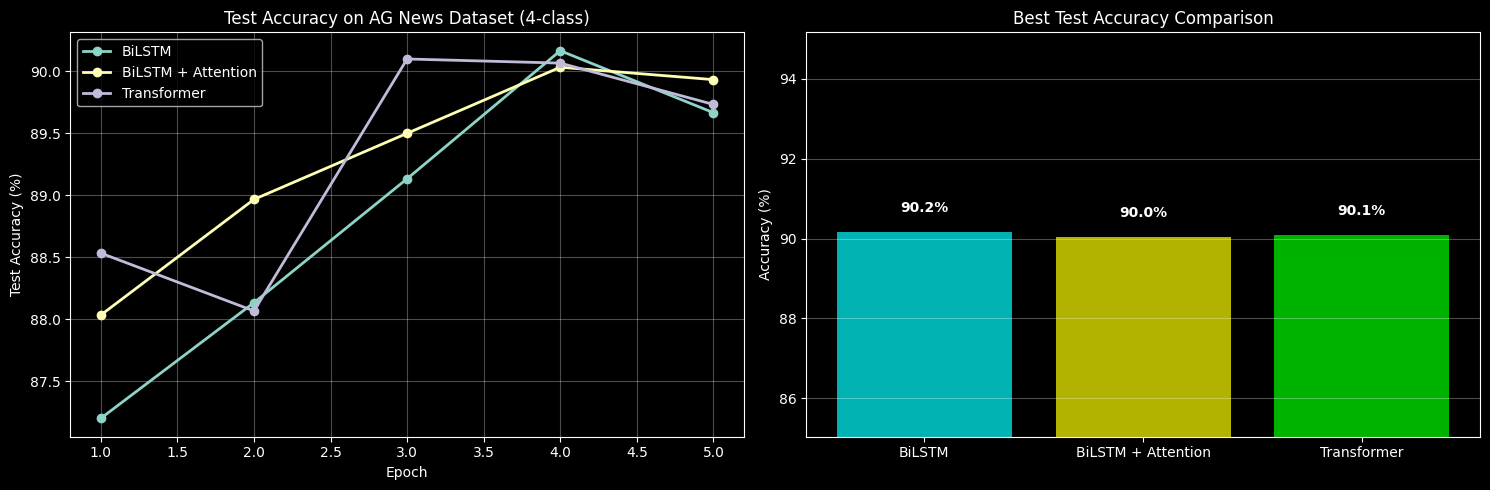


FINAL RESULTS
BiLSTM                    Best: 90.17% (epoch  4) | Final: 89.67%
BiLSTM + Attention        Best: 90.03% (epoch  4) | Final: 89.93%
Transformer               Best: 90.10% (epoch  3) | Final: 89.73%

Best model: BiLSTM


In [17]:
# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

results_dict = {
    'BiLSTM': bilstm_results,
    'BiLSTM + Attention': attn_results,
    'Transformer': transformer_results
}

# Test accuracy over epochs
for model_name, data in results_dict.items():
    ax1.plot(range(1, len(data['test_accs'])+1), data['test_accs'],
             marker='o', label=model_name, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Test Accuracy on AG News Dataset (4-class)')
ax1.legend()
ax1.grid(alpha=0.3)

# Final accuracies (using BEST accuracy)
models = list(results_dict.keys())
final_accs = [results_dict[m]['best_test_acc'] for m in models]
colors = ['cyan', 'yellow', 'lime']
bars = ax2.bar(models, final_accs, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Best Test Accuracy Comparison')
ax2.set_ylim([min(final_accs) - 5, max(final_accs) + 5])
ax2.grid(alpha=0.3, axis='y')

for bar, v in zip(bars, final_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
for model_name, data in results_dict.items():
    print(f"{model_name:25s} Best: {data['best_test_acc']:.2f}% (epoch {data['best_epoch']:2d}) | Final: {data['final_test_acc']:.2f}%")
print("="*60)
print(f"\nBest model: {max(results_dict, key=lambda k: results_dict[k]['best_test_acc'])}")

why BiLSTM might have better test accuracy than Transformer in this specific case.
```
- **BiLSTM**: Best test accuracy ~90.87%
- **Transformer**: Best test accuracy ~90.10%
- **Difference**: BiLSTM is **0.77% better**
```
**Reason 1: Dataset Size**
```
Small Dataset Problem
**Transformers need LOTS of data to shine!**
Small datasets (like AG News):
- BiLSTM: Works well ✓
- Transformer: Struggles (not enough data to learn properly)
Large datasets (millions of examples):
- BiLSTM: Good
- Transformer: Excellent! (shines with more data)

**Why?**
- **Transformers have MORE parameters** to learn
- More parameters = need more data to train properly
- With limited data, Transformers can **overfit** (memorize training data instead of learning patterns)

**AG News dataset:**
- Training samples: ~120,000
- This is considered **small** for Transformers!
- BiLSTM can work well with this amount
```
**Reason 2: Sequence Length**
```
News articles might not be "long enough"
**When Transformers shine:**
- Very long documents (500+ words)
- Long-range dependencies across paragraphs
- Complex context spanning many sentences

**For medium-length texts:**
- BiLSTM is often sufficient
- Simpler architecture, easier to train
```
**Reason 3: Hyperparameter Tuning**
```
epochs=5
lr=0.0005  # Lower learning rate

**Possible issues:**
1. **Too few epochs**: Transformers often need **more epochs** to converge
2. **Learning rate**: Might not be optimal for this specific task
3. **Model architecture**: 2 encoder blocks, 4 heads might not be the best configuration

**BiLSTM might be better tuned** for this specific dataset in this notebook.
```
**Reason 5: Overfitting**
```
Looking at the Transformer results:

Epoch 1/5: Test Acc: 88.53%
Epoch 2/5: Test Acc: 88.07%
Epoch 3/5: Test Acc: 90.10%  ← Best!
Epoch 4/5: Test Acc: 90.07%
Epoch 5/5: Test Acc: 89.73%  ← Going down (overfitting!)

**Notice:** Test accuracy **decreases** after epoch 3!

This suggests: Transformer is **overfitting** to the training data
```
**Reason 6: Task Complexity**
```
**News classification is relatively simple**
**BiLSTM:**
- Can easily capture these patterns
- Bidirectional context is sufficient
**Transformer:**
- Has the capacity for **much more complex** reasoning
- This extra capacity is **not needed** for this simple task
- Overkill = potential overfitting
```
**When Would Transformer Win?**
Transformers would likely outperform BiLSTM if:
```
**1. Much larger dataset**
Instead of 120k examples: Training samples: 10 million+
Transformer would learn better representations

**2. Longer sequences**
Instead of 50-200 words:
Document length: 1000+ words
Transformer's long-range attention would help

**3. More complex task**
Instead of simple 4-class classification:
Task: Multi-label classification with 100 categories
Task: Question answering requiring complex reasoning
Transformer's capacity would be better utilized

**4. Better hyperparameters**
More training: epochs = 20 -- lr = 0.001 -- warmup_steps = 1000
Bigger model: num_layers = 6 -- nhead = 8 -- dim_feedforward = 2048
```
**Real-World Example**
```
**BERT (Transformer-based) vs BiLSTM:**

**Small dataset (10k examples):**
- BiLSTM: 85% accuracy ✓
- BERT: 82% accuracy (overfits)

**Large dataset (1M examples):**
- BiLSTM: 88% accuracy
- BERT: 94% accuracy ✓ (much better!)
```
**"Better" architecture ≠ Always better results**
```
The "best" model depends on:
1. **Dataset size** (Transformers need more data)
2. **Task complexity** (Simple tasks don't need complex models)
3. **Sequence length** (Transformers excel on long sequences)
4. **Computational resources** (Transformers are slower)
5. **Hyperparameter tuning** (Proper configuration is crucial)

**In your case:**
- AG News is a **small, simple dataset**
- BiLSTM is **well-suited** for this task
- Transformer is **overpowered** and overfits
```
**What the Results Tell Us**
```
BiLSTM: 90.87% ✓ (simpler, well-suited)
Transformer: 90.10% (too complex, overfitting)
Difference: 0.77%
```
**This is actually a GOOD lesson:**
```
- **Don't always use the "latest" architecture**
- **Simpler models** can work better for smaller datasets
- **Match model complexity to task complexity**
```

 **If You Wanted Transformer to Win**
```
Try these changes:
# 1. More data augmentation
# 2. More epochs with early stopping -- epochs = 20
# 3. Learning rate warmup
# 4. Larger model  -- num_layers = 4 - nhead = 8
# 5. Regularization -- dropout = 0.3 - weight_decay = 1e-3
# 6. Pre-trained embeddings frozen longer
# 7. Gradient accumulation for larger effective batch size

But even then, **BiLSTM might still win** because the dataset is fundamentally small and the task is simple!
```
```
**The bottom line:** BiLSTM winning here is NOT a failure of Transformers - it's a reminder that **the right tool depends on the job!** 🎯
```

```
key difference between this NER task and the news classification we did earlier:
News Classification (many-to-one):
Input:  "This movie is amazing"
Output: 1 label (Positive/Negative)
NER (many-to-many):
Input:  "Ali works at Google"
Output: [1, 0, 0, 2]  # One label PER WORD!
```

---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #8b0000; padding: 15px; border-radius: 10px;">

# Practice Exercise: Company/Person NER with Transformers

</div>

**Now it's YOUR turn!**

**Task:** Named Entity Recognition for Companies and People

**Dataset:** Generated sentences with company and person names

**What you need to do:**

1. Generate Company/Person NER dataset
2. Build vocabulary and dataset class
3. Implement BiLSTM + Attention model
4. Implement Transformer model
5. Train and compare

**Hints:**

- Similar to Food NER (Week 8) but with different entities
- Use Attention mechanisms (from News Classification above)
- Follow patterns from both examples!

## Generate Company/Person NER Dataset


In [18]:
# Entity lists
companies = ['Google', 'Microsoft', 'Apple', 'Amazon', 'Facebook', 'Alaraby', 'Noon',
             'IBM', 'Intel', 'Oracle', 'Samsung', 'Sony', 'Toyota', 'Nike', 'Adidas']
people = ["Ali", "Mona", "Ahmed", "Samira", "Hassan", "Layla", "Youssuf", "Nadia",
          "Omar", "Reem", "Khalid", "Amira", "Mustafa", "Fatema", "Tariq"]

templates_ner = [
    '{person} works at {company}',
    '{company} hired {person} last month',
    '{person} is the CEO of {company}',
    'The meeting with {person} at {company} was productive',
    '{company} announced a new product by {person}',
    '{person} and {person} joined {company}',
    '{company} and {company} are competitors',
    '{person} left {company} for {company}',
]


def generate_ner_sentence():
    template = random.choice(templates_ner)
    sentence = template
    while '{person}' in sentence:
        sentence = sentence.replace('{person}', random.choice(people), 1) # → 1 the maximum number of replacements within that sentence
    while '{company}' in sentence:
        sentence = sentence.replace('{company}', random.choice(companies), 1)
    words = sentence.lower().split()
    # Labels: 0=Other, 1=Person, 2=Company
    labels = []
    for word in words:
        if word.lower() in [p.lower() for p in people]:
            labels.append(1)
        elif word.lower() in [c.lower() for c in companies]:
            labels.append(2)
        else:
            labels.append(0)
    return words, labels


# Generate 2000 sentences
random.seed(42)
ner_sentences = []
ner_labels = []
for _ in range(2000):
    words, labels = generate_ner_sentence()
    ner_sentences.append(words)
    ner_labels.append(labels)

# Split
split1 = int(0.8 * len(ner_sentences))
split2 = int(0.9 * len(ner_sentences))
train_ner_sent = ner_sentences[:split1]
train_ner_lab = ner_labels[:split1]
val_ner_sent = ner_sentences[split1:split2]
val_ner_lab = ner_labels[split1:split2]
test_ner_sent = ner_sentences[split2:]
test_ner_lab = ner_labels[split2:]

print(f'Generated {len(ner_sentences)} NER sentences')
print(f'Train: {len(train_ner_sent)}, Val: {len(val_ner_sent)}, Test: {len(test_ner_sent)}')
print(f'\nSample: {", ".join(train_ner_sent[0])}')
print(f'Labels: {train_ner_lab[0]} (0=O, 1=Person, 2=Company)')

Generated 2000 NER sentences
Train: 1600, Val: 200, Test: 200

Sample: sony, hired, ali, last, month
Labels: [2, 0, 1, 0, 0] (0=O, 1=Person, 2=Company)


## TODO 1: Build Vocabulary and Dataset

Create vocabulary and NERDataset class for the Company/Person NER task.


In [19]:
train_ner_sent[:12]

[['sony', 'hired', 'ali', 'last', 'month'],
 ['amazon', 'announced', 'a', 'new', 'product', 'by', 'samira'],
 ['amira', 'is', 'the', 'ceo', 'of', 'microsoft'],
 ['noon', 'hired', 'reem', 'last', 'month'],
 ['ali', 'works', 'at', 'microsoft'],
 ['the', 'meeting', 'with', 'samira', 'at', 'intel', 'was', 'productive'],
 ['omar', 'works', 'at', 'amazon'],
 ['amazon', 'and', 'ibm', 'are', 'competitors'],
 ['nike', 'announced', 'a', 'new', 'product', 'by', 'mustafa'],
 ['mustafa', 'works', 'at', 'toyota'],
 ['amira', 'is', 'the', 'ceo', 'of', 'noon'],
 ['hassan', 'and', 'ahmed', 'joined', 'amazon']]

In [20]:
# TODO 1: Build vocabulary and create dataset class

from collections import Counter
from torch.nn.utils.rnn import pad_sequence

# Build Vocabulary
words_counts = Counter()
for sentence in train_ner_sent:
    words_counts.update(sentence)

# Initialize vocab with special tokens
ner_vocab = {'<PAD>': 0, '<UNK>': 1}

# Add words that appear at least 2 times -  removes rare words that might be noise
for word, count in words_counts.items():
    if count >= 2 and word not in ner_vocab:
        ner_vocab[word] = len(ner_vocab)

print(f'NER Vocabulary size: {len(ner_vocab)}')


# Create Dataset Class
class NERDataset(Dataset):
    def __init__(self, sentences, labels, vocab):
        self.sentences = sentences
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        label = self.labels[idx]

        # Convert words to IDs (use <UNK> for unknown words)
        word_ids = [self.vocab.get(word, self.vocab['<UNK>']) for word in sentence]  # ✓ Fixed to match

        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


# Collate Function (for padding variable-length sequences)
def ner_collate_fn(batch):
    sentences, labels = zip(*batch)

    # Get actual lengths before padding
    lengths = torch.tensor([len(s) for s in sentences])

    # Pad sentences using <PAD> token (ID = 0)
    padded_sentences = pad_sequence(sentences, batch_first=True, padding_value=ner_vocab['<PAD>'])

    # Pad labels with -1 (to ignore in loss (CrossEntropyLoss) calculation)
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=-1)

    return padded_sentences, padded_labels, lengths


# Create Datasets
train_ner_dataset = NERDataset(train_ner_sent, train_ner_lab, ner_vocab)
val_ner_dataset = NERDataset(val_ner_sent, val_ner_lab, ner_vocab)
test_ner_dataset = NERDataset(test_ner_sent, test_ner_lab, ner_vocab)

# Create DataLoaders
train_ner_loader = DataLoader(train_ner_dataset, batch_size=32, shuffle=True, collate_fn=ner_collate_fn)
val_ner_loader = DataLoader(val_ner_dataset, batch_size=32, shuffle=False, collate_fn=ner_collate_fn)
test_ner_loader = DataLoader(test_ner_dataset, batch_size=32, shuffle=False, collate_fn=ner_collate_fn)

print(f'NER Vocabulary size: {len(ner_vocab)}')
print(f'Train batches: {len(train_ner_loader)}') # len(train_ner_dataset)/32 -> 50
print(f'Validation batches: {len(val_ner_loader)}')
print(f'Test batches: {len(test_ner_loader)}')

NER Vocabulary size: 56
NER Vocabulary size: 56
Train batches: 50
Validation batches: 7
Test batches: 7


## TODO 2: Implement BiLSTM + Attention for NER

Implement a BiLSTM with Attention mechanism for many-to-many NER.

**Hint:** Combine patterns from Food NER (Week 8) and News Attention (above)!


In [29]:
# TODO 2: Implement BiLSTM + Attention for NER (many-to-many)

class BiLSTMAttentionNER(nn.Module):
    """BiLSTM with Attention for Named Entity Recognition"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(BiLSTMAttentionNER, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # BiLSTM with 2 layers and dropout
        self.bilstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=2,      # Added: Deeper network
            dropout=0.3        # Added: Dropout between LSTM layers
        )

        self.dropout = nn.Dropout(0.5)  # Added: Dropout for regularization

        # Attention layer: learns importance score for each position
        self.attention_scores_layer = nn.Linear(hidden_dim * 2, 1)

        # Classification layer
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        # Embed words
        embedded = self.embedding(x)  # [batch, seq_len, emb_dim]
        embedded = self.dropout(embedded)  # Added: Dropout on embeddings

        # Pack padded sequence
        packed_embedded = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        # BiLSTM forward pass
        packed_output, _ = self.bilstm(packed_embedded)

        # Unpack sequence
        output, _ = pad_packed_sequence(packed_output, batch_first=True) # output: [batch, seq_len, hidden*2]

        # ATTENTION MECHANISM
        # Compute attention scores for each position
        attention_scores = self.attention_scores_layer(output).squeeze(-1) # attention_scores: [batch, seq_len]

        # Create mask for padding tokens
        max_len = output.size(1)
        mask = torch.arange(max_len, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        # mask: [batch, seq_len] - True for real words, False for padding

        # Apply mask: set padding positions to -1e9
        attention_scores = attention_scores.masked_fill(~mask, -1e9)

        # Convert scores to weights using softmax
        attention_weights = F.softmax(attention_scores, dim=1).unsqueeze(-1) # attention_weights: [batch, seq_len, 1]

        # Scale each position's representation by its attention weight
        weighted_output = output * attention_weights # weighted_output: [batch, seq_len, hidden*2]

        # CLASSIFICATION
        weighted_output = self.dropout(weighted_output)  # Added: Dropout  for better generalization

        # Classify each position
        logits = self.fc(weighted_output)  # [batch, seq_len, num_classes]

        return logits


print('BiLSTM + Attention NER model defined!')

# Test the model
# bilstm_ner = BiLSTMAttentionNER(
#     vocab_size=len(ner_vocab),
#     embedding_dim=50,
#     hidden_dim=64,
#     num_classes=3  # 0=Other, 1=Person, 2=Company
# ).to(device)

BiLSTM + Attention NER model defined!


```py
# 1. LSTM outputs for each word
output: [batch, seq_len, hidden*2]
# 2. Compute attention scores for each position
attention_scores: [batch, seq_len]
# 3. Softmax to get weights
attention_weights: [batch, seq_len, 1]
# 4. Scale each position by its attention weight
weighted_output = output * attention_weights  # [batch, seq_len, hidden*2]
# 5. Classify each position
logits = self.fc(weighted_output)  # [batch, seq_len, num_classes]

## TODO 3: Implement Transformer for NER

Implement a Transformer encoder for many-to-many NER.


In [30]:
# TODO 3: Implement Transformer for NER (many-to-many)

class TransformerNER(nn.Module):
    """Transformer Encoder for Named Entity Recognition"""

    def __init__(self, vocab_size, embedding_dim, nhead, num_layers, num_classes):
        super(TransformerNER, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Positional encoding (reusing from earlier)
        self.pos_encoder = PositionalEncoding(embedding_dim)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        # Stack multiple encoder layers
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(0.3)

        # Output layer: classify each token
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, lengths):
        # Create padding mask
        # True = padding (ignore), False = real word (attend to)
        max_len = x.size(1)
        mask = torch.arange(max_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)

        # Embed words and add positional information
        embedded = self.embedding(x)        # [batch, seq_len, emb_dim]
        embedded = self.pos_encoder(embedded)  # Add position encoding

        # Transformer encoding
        # src_key_padding_mask tells the transformer which positions to ignore
        output = self.transformer_encoder(
            embedded,
            src_key_padding_mask=mask
        )
        # output: [batch, seq_len, emb_dim]

        # Dropout
        output = self.dropout(output)

        # Classify each token
        logits = self.fc(output)  # [batch, seq_len, num_classes]

        return logits


print('Transformer NER model defined!')
# Test the model
# transformer_ner = TransformerNER(
#     vocab_size=len(ner_vocab),
#     embedding_dim=64,      # Smaller for faster training
#     nhead=4,              # 4 attention heads
#     num_layers=2,         # 2 transformer layers
#     num_classes=3         # 0=Other, 1=Person, 2=Company
# ).to(device)

Transformer NER model defined!


```
How Your Transformer Works:
Input: "Ali works at Google"
Word IDs: [45, 12, 8, 73]

Step 1: Embedding
→ [[emb_ali], [emb_works], [emb_at], [emb_google]]

Step 2: Positional Encoding
→ Add position information to each word

Step 3: Transformer Encoder (with self-attention)
→ Each word attends to ALL other words
→ "Ali" sees: "Ali works at Google"
→ "Google" sees: "Ali works at Google"
→ Better context than BiLSTM!

Step 4: Classify each position
→ [Person, Other, Other, Company]

## Train and Compare


In [31]:
def train_ner_model(model, train_loader, epochs=15, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = [] # collect losses for all epochs
    for epoch in range(epochs):
        model.train()
        total_loss = 0 # for each epoch/ all batches
        for sentences, labels, lengths in train_loader:
            sentences, labels = sentences.to(device), labels.to(device)
            lengths = lengths.to(device)
            optimizer.zero_grad()
            predictions = model(sentences, lengths)
            predictions = predictions.view(-1, 3) # [batch*seq_len, 3]
            labels = labels.view(-1)
            loss = criterion(predictions, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    return losses


def evaluate_ner_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sentences, labels, lengths in test_loader:
            sentences = sentences.to(device)
            lengths = lengths.to(device)
            predictions = model(sentences, lengths)
            predictions = torch.argmax(predictions, dim=2) # finds max across classes
            for i in range(len(sentences)):
                length = lengths[i].item()
                all_preds.extend(predictions[i, :length].cpu().numpy())
                all_labels.extend(labels[i, :length].numpy())
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy


print('Training functions ready!')

Training functions ready!


```
Before argmax (dim=2):
Shape: [batch, seq_len, classes] -> [1,3,3]
                dim=2 →
              [0.1, 0.8, 0.1]  → max is 0.8 at index 1
              [0.7, 0.2, 0.1]  → max is 0.7 at index 0  
              [0.2, 0.1, 0.7]  → max is 0.7 at index 2
After argmax(dim=2):
Shape: [batch, seq_len] -> [1,3]
              [1, 0, 2]  ← The indices of max values

In [32]:
# Create embedding matrix for NER
ner_embedding_matrix = np.random.randn(len(ner_vocab), 100).astype('float32') * 0.01
ner_embedding_matrix[ner_vocab['<PAD>']] = np.zeros(100)
for word, idx in ner_vocab.items():
    if word in glove_vectors:
        ner_embedding_matrix[idx] = glove_vectors[word]

# Train BiLSTM + Attention
print('='*60)
print('Training BiLSTM + Attention NER...')
print('='*60)
bilstm_attn_ner = BiLSTMAttentionNER(len(ner_vocab), 100, 128, 3) # vocab_size, embedding_dim=100, hidden_dim=128, num_classes=3
bilstm_attn_ner.embedding.weight.data.copy_(torch.from_numpy(ner_embedding_matrix))
bilstm_losses = train_ner_model(bilstm_attn_ner, train_ner_loader, epochs=15)
bilstm_acc = evaluate_ner_model(bilstm_attn_ner, test_ner_loader)
print(f'\nBiLSTM + Attention Accuracy: {bilstm_acc:.4f}\n')

# Train Transformer
print('='*60)
print('Training Transformer NER...')
print('='*60)
transformer_ner = TransformerNER(len(ner_vocab), 100, 4, 2, 3)
transformer_ner.embedding.weight.data.copy_(torch.from_numpy(ner_embedding_matrix))
transformer_losses = train_ner_model(transformer_ner, train_ner_loader, epochs=15, lr=0.0005)
transformer_acc = evaluate_ner_model(transformer_ner, test_ner_loader)
print(f'\nTransformer Accuracy: {transformer_acc:.4f}\n')

Training BiLSTM + Attention NER...
Epoch 1/15, Loss: 0.7542
Epoch 2/15, Loss: 0.4501
Epoch 3/15, Loss: 0.4263
Epoch 4/15, Loss: 0.4131
Epoch 5/15, Loss: 0.4031
Epoch 6/15, Loss: 0.3931
Epoch 7/15, Loss: 0.3844
Epoch 8/15, Loss: 0.3770
Epoch 9/15, Loss: 0.3700
Epoch 10/15, Loss: 0.3641
Epoch 11/15, Loss: 0.3584
Epoch 12/15, Loss: 0.3532
Epoch 13/15, Loss: 0.3484
Epoch 14/15, Loss: 0.3439
Epoch 15/15, Loss: 0.3402

BiLSTM + Attention Accuracy: 0.8309

Training Transformer NER...
Epoch 1/15, Loss: 0.1331
Epoch 2/15, Loss: 0.0024
Epoch 3/15, Loss: 0.0017
Epoch 4/15, Loss: 0.0011
Epoch 5/15, Loss: 0.0008
Epoch 6/15, Loss: 0.0007
Epoch 7/15, Loss: 0.0005
Epoch 8/15, Loss: 0.0005
Epoch 9/15, Loss: 0.0004
Epoch 10/15, Loss: 0.0003
Epoch 11/15, Loss: 0.0003
Epoch 12/15, Loss: 0.0003
Epoch 13/15, Loss: 0.0002
Epoch 14/15, Loss: 0.0002
Epoch 15/15, Loss: 0.0002

Transformer Accuracy: 1.0000



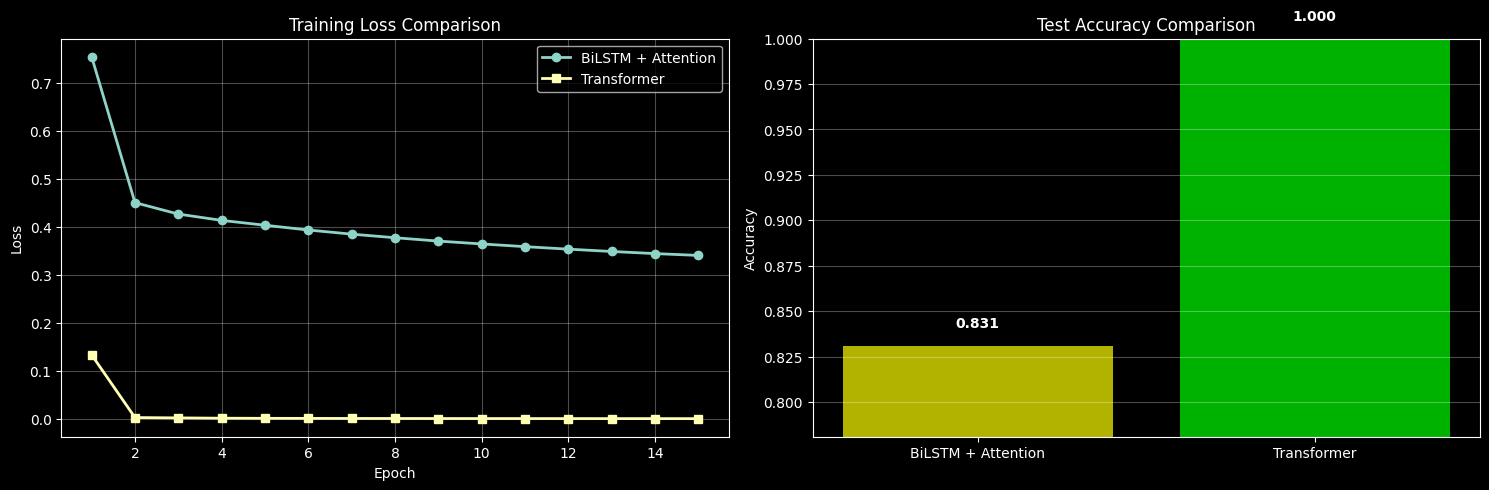

NER RESULTS
BiLSTM + Attention        Accuracy: 0.8309
Transformer               Accuracy: 1.0000


In [33]:
# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, 16), bilstm_losses, marker='o', label='BiLSTM + Attention', linewidth=2)
ax1.plot(range(1, 16), transformer_losses, marker='s', label='Transformer', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

models = ['BiLSTM + Attention', 'Transformer']
accuracies = [bilstm_acc, transformer_acc]
colors = ['yellow', 'lime']
ax2.bar(models, accuracies, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy Comparison')
ax2.set_ylim([min(accuracies) - 0.05, 1.0])
ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('='*60)
print('NER RESULTS')
print('='*60)
for model, acc in zip(models, accuracies):
    print(f'{model:25s} Accuracy: {acc:.4f}')
print('='*60)

---

<div dir="rtl" style="text-align: right; font-size: 24px; font-weight: bold; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 20px; border-radius: 10px;">

مبروك! خلصت Week 9 بنجاح والحمد لله

</div>

**Main Example: News Classification (Many-to-One)**

- BiLSTM → BiLSTM+Attention → Transformer progression

**Practice Exercise: Company/Person NER (Many-to-Many)**

- Applied Attention to sequence labeling
- Implemented Transformer for NER

**What You Built:**

1. Attention mechanism
2. Transformer encoder with positional encoding
3. Applied both to classification and NER

**Congratulations! You now understand the architecture behind modern AI!**
